<a href="https://colab.research.google.com/github/IvanIri/Aprendizaje-Automatico-2/blob/main/TP1_AA2_Regresi%C3%B3n_Iv%C3%A1n_Irigoyen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP1 AA1

**Iván Irigoyen**

## Indicaciones básicas

0) Debe usar este notebook como template para su entrega. Haga una copia y comience a completar las consignas.

1) Cada uno debe completar las consignas indicadas en este notebook.

2)
3) No pueden repetir el mismo dataset que ya haya definido un compañero.

4) copias explícitas de secciones enteras del trabajo de otro será penalizado disminuyendo su puntuación.

5) No se olvide de añadir las fuentes de inspiración de su código (blogs, prompts de chatgpt o similar).

6) Además de todo el código que agregue, es importante que sepa interpretarlo. Agregue texto explicativo en cada sección. Esto le ayudará al momento del coloquio / parcial

7) Revise las fecha límite de entrega de este trabajo

# ENTREGA

* En el foro destinado a la tarea debe postear al menos tres veces:
  - La primera vez para indicar el dataset elegido
  - Una segunda vez para postear su entrega
  - Una tercera vez para brindar feedback a alguien más en el foro.
  - Puede comentar más de un posteo de sus compañeros siempre y cuando el intercambio sea respetuoso y fructífero.
* Deben postear como solución un enlace a su notebook colab público y también un enlace al mismo notebook alojado en su repositorio GitHub.
* Debe sumar el enlace a un video donde muestre su solución y explique lo realizado. Duración máxima: 5 minutos. Puede grabarse a Ud. mismo usando una sesión de zoom y grabar localmente. Puede subir el video a su youtube personal como privado o Unlisted.
* Enlaces no accesibles o enlaces erróneos es igual a determinar que la tarea no ha sido entregada. Corrobore la viabilidad de los enlaces que postea.


#**Tarea: Aplicación de Regresión Lineal y Análisis de Importancia de Variables**  
**Objetivo**: Aplicar un modelo de regresión lineal a un dataset de su elección, evaluar su rendimiento e identificar las variables más relevantes para la predicción.

---

# **Instrucciones**:

#1. **Selección del Dataset**  
   - Elijan un dataset de UCI ML Repository del siguiente enlace: https://archive.ics.uci.edu/datasets/?Task=Regression&skip=0&take=10&sort=desc&orderBy=NumHits&search=  
   - Requisitos:  
     - Debe tener al menos 4 variables numéricas continuas (1 target, 3 o más features).  
     - Idealmente, que las features tengan distintas escalas o unidades ( no excluyente).
     - Revisar en el foro de la tarea que dicho dataset no haya sido ya elegido por otra persona.
     - Postee en el foro de la tarea el dataset que eligió. Continue al siguiente punto.  



## Resolución:

In [23]:
# Conversion del archivo a formato csv

import pandas as pd

columnas = [
    "mpg", "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year", "origin", "car_name"
]

In [24]:
# Traer el dataset con formato csv.

from google.colab import drive
drive.mount('/content/drive')

url = '/content/drive/MyDrive/Carrera Cs. Datos/Aprendizaje Automatico 1/auto-mpg.csv'

autos_mpg = pd.read_csv(url, sep= ",", names= columnas, na_values="?", skiprows= 1)

autos_mpg.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino



## 2. **Análisis exploratorio (previo al modelado)**  
   - Describan las variables (media, distribución, outliers).  
   - Visualizen:  
     - Histogramas o boxplots para ver distribuciones.  
     - Gráficos de dispersión (scatterplots) entre features y target.  
   - **Pregunta clave**: ¿Qué relaciones lineales preliminares observan?  


## Resolución:

In [25]:
# importo las librerias necesarias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

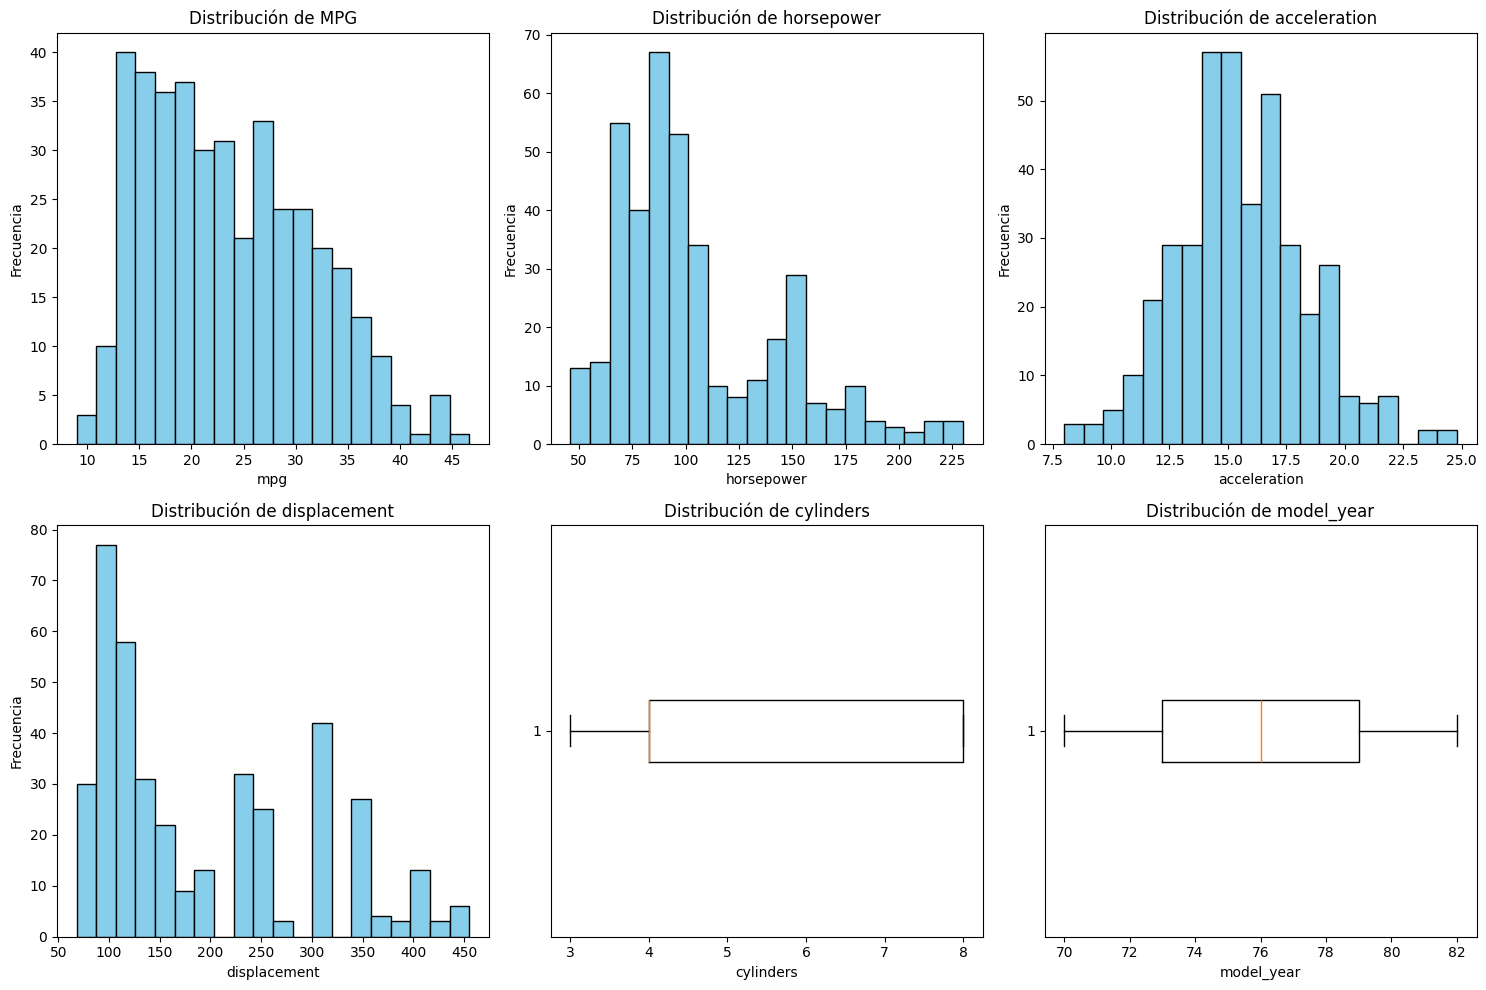

In [26]:
# Graficos de las variables.

variables = ["mpg", "cylinders", "horsepower", "acceleration", "model_year"]

plt.figure(figsize = (15, 10))

# Histogramas

plt.subplot(2, 3, 1)
plt.hist(autos_mpg["mpg"], bins= 20, color = "skyblue", edgecolor ="black")
plt.title("Distribución de MPG")
plt.xlabel("mpg")
plt.ylabel("Frecuencia")

plt.subplot(2, 3, 2)
plt.hist(autos_mpg["horsepower"], bins= 20, color = "skyblue", edgecolor ="black")
plt.title("Distribución de horsepower")
plt.xlabel("horsepower")
plt.ylabel("Frecuencia")

plt.subplot(2, 3, 3)
plt.hist(autos_mpg["acceleration"], bins= 20, color = "skyblue", edgecolor ="black")
plt.title("Distribución de acceleration")
plt.xlabel("acceleration")
plt.ylabel("Frecuencia")

plt.subplot(2, 3, 4)
plt.hist(autos_mpg["displacement"], bins= 20, color = "skyblue", edgecolor ="black")
plt.title("Distribución de displacement")
plt.xlabel("displacement")
plt.ylabel("Frecuencia")

# Boxplots

plt.subplot(2, 3, 5)
plt.boxplot(autos_mpg["cylinders"], vert= False)
plt.title("Distribución de cylinders")
plt.xlabel("cylinders")

plt.subplot(2, 3, 6)
plt.boxplot(autos_mpg["model_year"], vert= False)
plt.title("Distribución de model_year")
plt.xlabel("model_year")

plt.tight_layout()
plt.show()

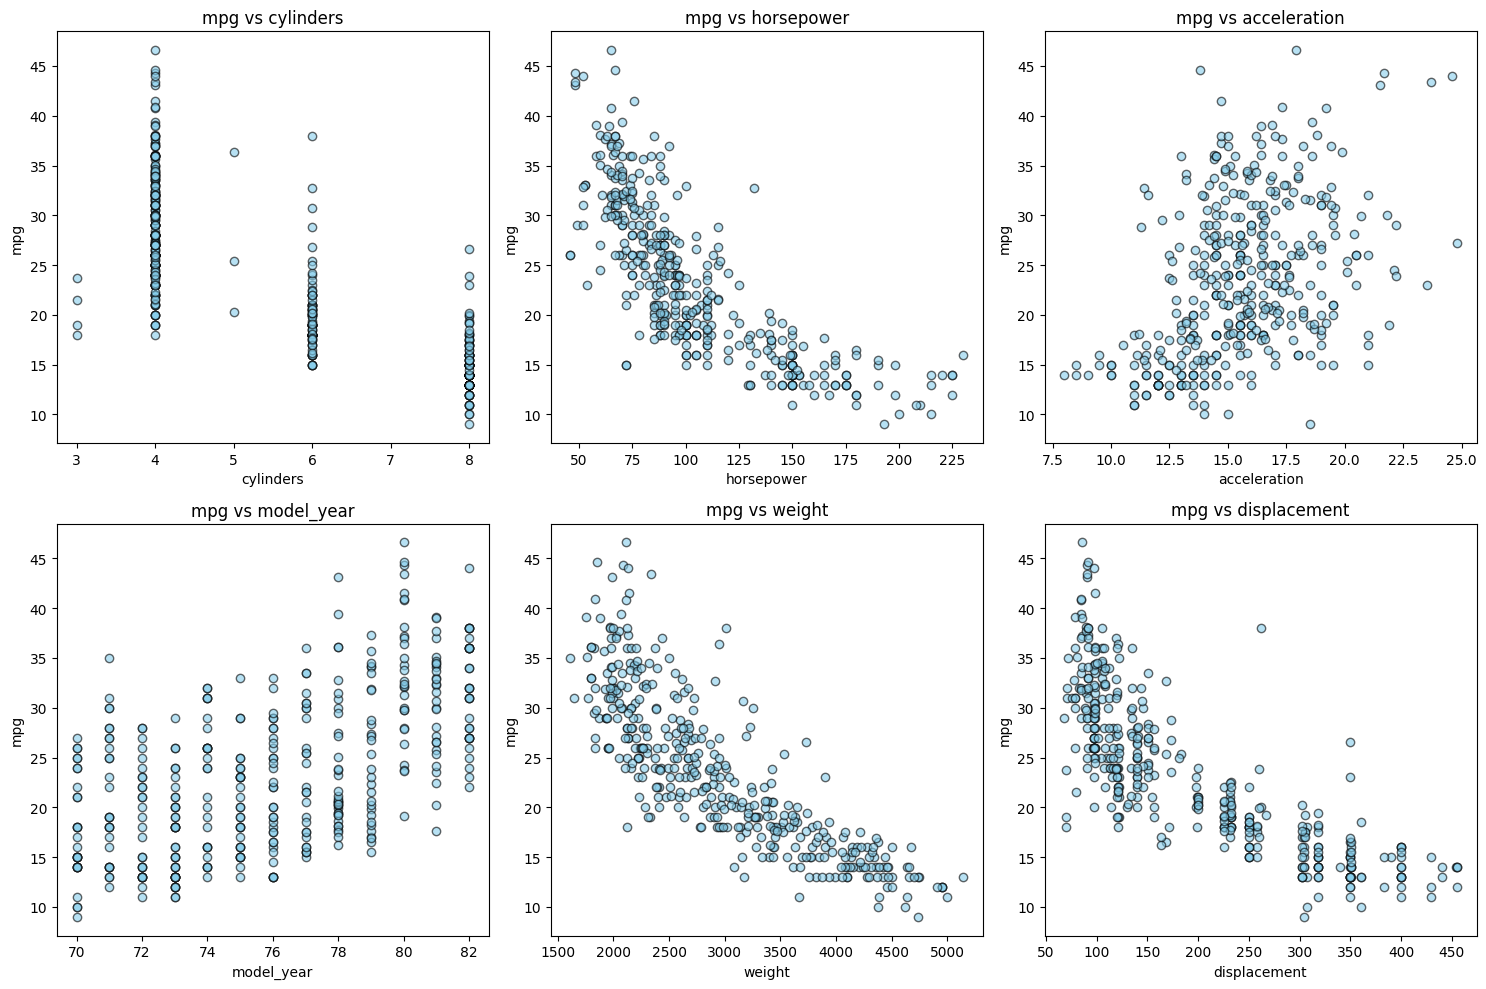

In [27]:
# Graficos de dispersión

variables = ["cylinders", "horsepower", "acceleration", "model_year", "weight", "displacement"]

plt.figure(figsize=(15, 10))

for i, var in enumerate(variables, 1):
    plt.subplot(2, 3, i)
    plt.scatter(autos_mpg[var], autos_mpg["mpg"], alpha=0.6, color="skyblue", edgecolor="black")
    plt.title(f"mpg vs {var}")
    plt.xlabel(var)
    plt.ylabel("mpg")

plt.tight_layout()
plt.show()

## Analisís de la relación entre MPG y el resto de variables.

Las primeras relaciones que se observan es por ejemplo entre MPG (millas por galon de combustible) y WEIGHT (peso del auto). Se observa claramente en el grafico de dispersión como este tiene menores valores a medida que el peso del vehiculo aumenta. Es decir, a mayor pesos menor distancia recorrida por galon de combustible. La misma relación negativa se observa cuando se compara MPG con HORSEPOWER (caballos de fuerza), a medida que la cantidad de HORSERPOWER aumenta, disminuye el MPG. Otra relación interesante es con CYLINDERS (cantidad de cilindros) que aunque es bastante dispar en valores como 4 CILINDROS, donde hay autos que consumen mucho y otros pocos se ve como al ir aumentando la cantidad de CILINDROS el MPG disminuye. Por ultimo cuando se lo compara con ACCELERATION (aceleración) se ve una relación que tiende a ser positiva, que al aumentar la ACELERACIÓN el MPG también aumenta, la aceleración es eficiente con el consumo de combustible.

## 3. **Preprocesamiento**  
   - Limpieza: Manejen missing values (eliminar, imputar) y outliers (si es necesario).  
   - Limpieza: indique cuáles features descarta. Justifique.
   - Indique si usará o no variables categóricas. Justifique. Realice su preprocesamiento adeucado.
   - Escalen las features (p.ej., StandardScaler) para comparar coeficientes después.  
   - Dividan en train/test (70-30 o 80-20).  

## Resolución:

In [28]:
# Valores nulos

autos_mpg.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
car_name,0


In [29]:
# Elimino los valores nulos encontrados

df_autos = autos_mpg.dropna()

In [30]:
# Descarte de features

autos = df_autos.drop(columns=["origin", "model_year"])
autos.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,ford torino


Decidi eliminar la columna "origin" y "model_year" ya que eran unas columnas de valores enteros que no aportaban valor al analisis. A la columna "car_name" la conserve para posible uso en el analisis final.

no utilizare variables categoricas por que lo que busco analizar es la implicancia de las variables en el valor de MPG y esta es una variable numerica continúa.

In [31]:
# Escalado de los features

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Seleccion de features y variable objetivo
X = autos[['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']]
y = autos['mpg']

# Escalamiento con StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns= X.columns)

# Entrenamiento del modelo
model = LinearRegression()
model.fit(X_scaled, y)

# Comparación de coeficientes
coef_autos = pd.DataFrame({
    'features': X_scaled.columns,
    'coef': model.coef_
})

print(coef_autos)

       features      coef
0     cylinders -0.677913
1  displacement -0.008688
2    horsepower -1.739774
3        weight -4.400158
4  acceleration -0.080193


In [32]:
# Creación del test

from sklearn.model_selection import train_test_split

X = autos[['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']]
y = autos['mpg']

# División del test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.3, random_state= 42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

coef_autos = pd.DataFrame({
    'features': X.columns,
    'coef': model.coef_
})
print(coef_autos)

r2_train = model.score(X_train_scaled, y_train)
r2_test = model.score(X_test_scaled, y_test)
print(f"R2 train: {r2_train:.3f}")
print(f"R2 test: {r2_test:.3f}")

       features      coef
0     cylinders -0.470738
1  displacement -0.597713
2    horsepower -2.128388
3        weight -3.956335
4  acceleration -0.152832
R2 train: 0.723
R2 test: 0.649


Al darnos todos los resultados de los coeficintes negativos, esto quiere decir que existe una relación negativa entre todas las variables y MPG. Esto es que todas las variables hacen que cuando estas aumentan el MPG disminuya. Es decir, cualquier cambio que hagamos, ya sea un aumento de HORSEPOWER o de CYLINDERS el MPG (millas por galon) disminuira, recorrera menos millas por galon de combustible. WEIGHT es el que más afecta y ACCELERATION el que menos.




## 4. **Regresión Lineal**  
   - Ajusten un modelo de regresión lineal (usando `sklearn.linear_model.LinearRegression`).  
   - Obtengan:  
     - Coeficientes (pesos) del modelo.  
     - Evaluar métricas en el set de entrenamiento y en el de testeo: **R²**, MSE (error cuadrático medio), MAE.  


In [33]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Vuelvo a definir features y target.
X = autos[['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']]
y = autos['mpg']

# Escalado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

coef = pd.DataFrame({
    "features": X.columns,
    "coef": model.coef_
})
print("Coeficientes: ", coef)

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

print("\nEntrenamiento: ")
print("R2: ", r2_score(y_train, y_train_pred))
print("MSE: ", mean_squared_error(y_train, y_train_pred))
print("MAE: ", mean_absolute_error(y_train, y_train_pred))

print("\nTesteo: ")
print("R2: ", r2_score(y_test, y_test_pred))
print("MSE: ", mean_squared_error(y_test, y_test_pred))
print("MAE: ", mean_absolute_error(y_test, y_test_pred))

Coeficientes:         features      coef
0     cylinders -0.298474
1  displacement -0.695438
2    horsepower -1.869394
3        weight -4.192104
4  acceleration -0.170065

Entrenamiento: 
R2:  0.7166422136497115
MSE:  17.879803779295006
MAE:  3.2187427154016586

Testeo: 
R2:  0.6485312110889081
MSE:  17.939171976631265
MAE:  3.486131803336791


Dado que el R2 de train y el R2 de test tienen poca diferencia se puede determinar que el modelo esta generalizado bastante bien.

El MAE tuvo una minima diferencia entre el train y test, en promedio tomaria un valor de 3,35. Esto significa que el modelo se equivoca en 3,35 MPG.


## 5. **Importancia de Variables**  
   - Analicen los **coeficientes** del modelo:  
     - Valores absolutos altos → mayor impacto en el target.  
     - Signo: Relación positiva/negativa con el target.  
   - Comparen la magnitud de los coeficientes **escalados** (si usaron features en distintas unidades).  
   - **5.1. Opcional**:
     Otra forma es "desordenar" un feature y ver cómo empeora el modelo. Si al desordenarlo el error aumenta mucho, ese feature era importante. Usen métodos como:  
     - **Permutation Importance** (de sklearn) para validar importancia. Más info en https://scikit-learn.org/stable/modules/permutation_importance.html



## Resolución:

## Coeficientes del modelo:

* Los coeficientes del modelo son todos negativos. Por lo tanto hay una relación negativa entre MPG y el resto de variables. Siempre que se aumente una de las variables features MPG disminuira (o tenderá).
* Los features tienen distinta implicancia en esta disminución de MPG. La que mas impacta con diferencia es WEIGHT, el peso del auto tiene mucho impacto en el MPG. luego le sigue HORSEPOWER todavía con bastante impacto, el resto de variables presentan un impacto bastante menor, siendo el tercero que mas influye DISPLACEMENT, luego CYLINDERS y por ultimo ACCELERATION siendo la que menos impacta y dando un valor cercano a 0.

In [34]:
# Comparación de coeficientes.

fig = px.bar(
    coef,
    x = "features",
    y = "coef",
    title = "Implicancia de cada coeficiente escalado",
    text = "coef",
    color = "coef",
    color_continuous_scale = "RdBu"
)

fig.update_traces(texttemplate= '%{text: .2f}', textposition= "outside")
fig.update_layout(yaxis_title = "Coeficiente escalado", xaxis_title = "Variable")

fig.show()


## 6. **Reflexión**  
   - ¿Cuáles variables son más importantes según el modelo? ¿Coincide con su análisis exploratorio?  
   - ¿El modelo tiene buen rendimiento (R² alto, MSE bajo)? Si no, ¿a qué podría deberse?  



## Resolución:

* Las variables mas importantes del modelo son WEIGHT y HORSEPOWER por que son las 2 mas influyentes con diferencia en el valor final de MPG. Son las dos variables con mayor coeficiente del modelo. Esto quiere decir que pequeñas modificaciones en una de esas variables puede afectar mucho al valor de MPG.

* En el analisis exploratorio ya se podía observar en el grafico de dispersión esta fuerte relación negativa de estas variables con MPG. Así que en principio coincidio el analisis exploratorio con el resultado del modelo. Exceptuando un caso, el de ACCELERATION, en el analisis exploratorio parecía haber una relación positiva entre esta variable y MPG, cosa que luego el modelo reflejo no ser así. El modelo otorgo un coeficiente negativo, esto indica que también existe una relación negativa, pero una muy pequeña, la cual no había sido posible ver en el grafico de dispersión.

* Si, el modelo tiene un buen rendimiento.
Tiene un R2 de 0,717 en train y de 0,649 en test. Son 2 valores altos que indican que el modelo generaliza bastante bien y como no hay una gran diferencia entre sus valores se puede decir que tampoco hay sobreajuste.
El MSE dio un valor de ~17,9 el cual es un valor bajo, pero no tanto, es un error medio.
Además el train dio un valor de 17,88 y el test de 17,94. Estos valores tan similares nos indican que no hay fuga de performance.


## **Bonus**:  
- Prueben eliminar variables "poco importantes" y reentrenar el modelo. ¿Mejora el rendimiento?  


---

### **Tips**:  
- Si el R² es muy bajo, revisen si hay relaciones no lineales (y consideren transformar features).  
- Documenten cada paso: ¡la trazabilidad es clave en ciencia de datos!  


# TP1 : MLP con Pytorch

### AA2

### Descargamos las bibliotecas necesarias, convertimos los datos a tensores y creamos la clase

In [35]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Convertimos los datos en tensores de Pytorch

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

In [36]:
# Vemos las dimensiones

print("X train:", X_train_tensor.shape)
print("y train:", y_train_tensor.shape)

print("X test:", X_test_tensor.shape)
print("y test:", y_test_tensor.shape)

X train: torch.Size([313, 5])
y train: torch.Size([313, 1])
X test: torch.Size([79, 5])
y test: torch.Size([79, 1])


In [37]:
# Creo el TensorDataset

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Verificamos
train_dataset[0]

(tensor([0.3049, 0.2846, 0.1414, 0.7548, 1.1218]), tensor([18.6000]))

In [38]:
# Ahora pasamos los datasets a dataloader

train_dataloader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [39]:
for xb, yb in train_dataloader:
    print(xb.shape)
    print(yb.shape)
    break

torch.Size([32, 5])
torch.Size([32, 1])


In [40]:
# Creamos la clase de la red

class RedRegresion(nn.Module):

    def __init__(self):
        super().__init__()

        self.red = nn.Sequential(
            nn.Linear(5, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.red(x)

Genero 5 neuronas ya que el dataset dispone de 5 features, luego usare 2 capaz ocultas de 16 y 8 neuronas para que la red aprenda las relaciones no lineales.

Para eso también usamos "RelU" y por ultimo la ultima capa tiene una sola neurona por q buscamos predecir un unico valor continúo, nuestra variable target "mpg".

In [41]:
# Instaciamos

modelo = RedRegresion()

print(modelo)

RedRegresion(
  (red): Sequential(
    (0): Linear(in_features=5, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)


### Entrenamiento de la red

In [42]:
# Funcion de perdida y optimizador

criterio = nn.MSELoss()

optimizador = torch.optim.Adam(
    modelo.parameters(),
    lr=0.001
)

In [44]:
# Entrenamiento de los datos

num_epocas = 200

for epoca in range(num_epocas):

    modelo.train()

    perdida_acumulada = 0

    for xb, yb in train_dataloader:

        # Limpiar gradientes anteriores
        optimizador.zero_grad()

        # Hacer la predicción
        predicciones = modelo(xb)

        # Calcular el error
        perdida = criterio(predicciones, yb)

        # Calcular los gradientes
        perdida.backward()

        # Actualizar los pesos
        optimizador.step()

        perdida_acumulada += perdida.item()

    perdida_promedio = perdida_acumulada / len(train_dataloader)

    if (epoca + 1) % 20 == 0:
        print(
            f"Época {epoca + 1}/{num_epocas} - "
            f"Loss: {perdida_promedio:.4f}"
        )

Época 20/200 - Loss: 13.8082
Época 40/200 - Loss: 13.9919
Época 60/200 - Loss: 13.8673
Época 80/200 - Loss: 13.6509
Época 100/200 - Loss: 13.5464
Época 120/200 - Loss: 13.3538
Época 140/200 - Loss: 13.2255
Época 160/200 - Loss: 13.1057
Época 180/200 - Loss: 13.1969
Época 200/200 - Loss: 13.2760


In [45]:
# Obtenemos las predicciones

modelo.eval()

with torch.no_grad():

    pred_train = modelo(X_train_tensor)
    pred_test = modelo(X_test_tensor)

In [46]:
pred_train = pred_train.numpy()
pred_test = pred_test.numpy()

### Calculo de metricas: MSE, MAE y R2

In [47]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# TRAIN
mse_train = mean_squared_error(y_train, pred_train)
mae_train = mean_absolute_error(y_train, pred_train)
r2_train = r2_score(y_train, pred_train)

# TEST
mse_test = mean_squared_error(y_test, pred_test)
mae_test = mean_absolute_error(y_test, pred_test)
r2_test = r2_score(y_test, pred_test)

print("Resultados TRAIN")
print(f"MSE: {mse_train:.4f}")
print(f"MAE: {mae_train:.4f}")
print(f"R²: {r2_train:.4f}")

print("\nResultados TEST")
print(f"MSE: {mse_test:.4f}")
print(f"MAE: {mae_test:.4f}")
print(f"R²: {r2_test:.4f}")

Resultados TRAIN
MSE: 13.1186
MAE: 2.6451
R²: 0.7921

Resultados TEST
MSE: 15.6747
MAE: 2.9232
R²: 0.6929


### Analisis del sobreajuste y subajuste

In [48]:
# Creamos otra clase donde podamos indicarle el numero de neuronas

class RedExperimento(nn.Module):

    def __init__(self, neuronas):
        super().__init__()

        self.red = nn.Sequential(
            nn.Linear(5, neuronas),
            nn.ReLU(),
            nn.Linear(neuronas, 1)
        )

    def forward(self, x):
        return self.red(x)

In [52]:
# Definimos la cantidad de neuronas que probaremos

torch.manual_seed(42)

neuronas_experimento = [2, 4, 8, 16, 32, 64, 128]

mse_train_lista = []
mse_test_lista = []

In [53]:
# Entrenamos el modelo para los distintos conjuntos de neuronas

for neuronas in neuronas_experimento:

    # Crear modelo
    modelo_exp = RedExperimento(neuronas)

    # Función de pérdida
    criterio = nn.MSELoss()

    # Optimizador
    optimizador = torch.optim.Adam(
        modelo_exp.parameters(),
        lr=0.001
    )

    # Entrenamiento
    for epoca in range(200):

        modelo_exp.train()

        for xb, yb in train_dataloader:

            optimizador.zero_grad()

            predicciones = modelo_exp(xb)

            perdida = criterio(predicciones, yb)

            perdida.backward()

            optimizador.step()

    # Evaluación
    modelo_exp.eval()

    with torch.no_grad():

        pred_train = modelo_exp(X_train_tensor)
        pred_test = modelo_exp(X_test_tensor)

        mse_train = criterio(pred_train, y_train_tensor).item()
        mse_test = criterio(pred_test, y_test_tensor).item()

    # Guardar resultados
    mse_train_lista.append(mse_train)
    mse_test_lista.append(mse_test)

    print(
        f"Neuronas: {neuronas:3d} | "
        f"MSE Train: {mse_train:.4f} | "
        f"MSE Test: {mse_test:.4f}"
    )

Neuronas:   2 | MSE Train: 65.3946 | MSE Test: 50.0070
Neuronas:   4 | MSE Train: 77.7681 | MSE Test: 63.0440
Neuronas:   8 | MSE Train: 32.4093 | MSE Test: 34.2517
Neuronas:  16 | MSE Train: 15.4919 | MSE Test: 17.8053
Neuronas:  32 | MSE Train: 14.8739 | MSE Test: 16.3752
Neuronas:  64 | MSE Train: 14.1308 | MSE Test: 15.9093
Neuronas: 128 | MSE Train: 13.6493 | MSE Test: 15.8899


### Grafico del resultado de los distintos conjuntos de neuronas

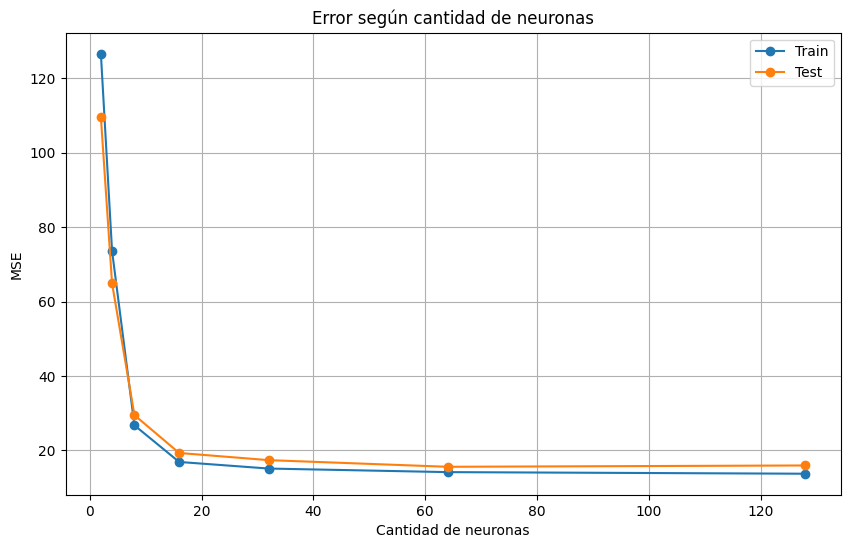

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    neuronas_experimento,
    mse_train_lista,
    marker="o",
    label="Train"
)

plt.plot(
    neuronas_experimento,
    mse_test_lista,
    marker="o",
    label="Test"
)

plt.xlabel("Cantidad de neuronas")
plt.ylabel("MSE")
plt.title("Error según cantidad de neuronas")
plt.legend()
plt.grid()

plt.show()

## Primera conclusión

Al variar la cantidad de neuronas se observa que las redes con 2 y 4 neuronas presentan errores elevados tanto en entrenamiento como en testeo, lo que indica un subajuste (underfitting), ya que la capacidad del modelo no es suficiente para representar adecuadamente los patrones de los datos. Al aumentar la cantidad de neuronas se produce una reducción considerable del error, especialmente entre 8 y 16 neuronas. A partir de 32 neuronas las mejoras son cada vez menores, observándose una estabilización del MSE. En este experimento no se observa un sobreajuste (overfitting) marcado, debido a que el error de testeo no aumenta al incrementar la cantidad de neuronas. Por este motivo, se realizará un segundo experimento aumentando la complejidad y el tiempo de entrenamiento de la red para analizar la posible aparición de sobreajuste.

## 2do modelo

Voy a crear una red más grande (con más neuronas y capas) donde vamos a observar el MSE de train y test epoca por epoca, esto para visualizar mejor si en algún momento empieza a memorizar train y se genera el sobreajuste.

In [55]:
# Creamos la clase e indicamos la cantidad de neuronas y capas

class RedGrande(nn.Module):

    def __init__(self):
        super().__init__()

        self.red = nn.Sequential(
            nn.Linear(5, 128),
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.red(x)

In [56]:
# creamos el modelo

torch.manual_seed(42)

modelo_grande = RedGrande()

criterio = nn.MSELoss()

optimizador = torch.optim.Adam(
    modelo_grande.parameters(),
    lr=0.001
)

In [57]:
# Listas para guardar los valores del MSE epoca por epoca

historial_train = []
historial_test = []

In [58]:
# Entrenamos el modelo durante 1000 epocas (5 veces más en el 1er modelo)

num_epocas = 1000

for epoca in range(num_epocas):

    # ENTRENAMIENTO
    modelo_grande.train()

    for xb, yb in train_dataloader:

        optimizador.zero_grad()

        predicciones = modelo_grande(xb)

        perdida = criterio(predicciones, yb)

        perdida.backward()

        optimizador.step()


    # EVALUACIÓN
    modelo_grande.eval()

    with torch.no_grad():

        pred_train = modelo_grande(X_train_tensor)
        pred_test = modelo_grande(X_test_tensor)

        mse_train = criterio(
            pred_train,
            y_train_tensor
        ).item()

        mse_test = criterio(
            pred_test,
            y_test_tensor
        ).item()


    # Guardamos los errores de esta época
    historial_train.append(mse_train)
    historial_test.append(mse_test)


    # Mostrar progreso cada 100 épocas
    if (epoca + 1) % 100 == 0:

        print(
            f"Época {epoca + 1:4d} | "
            f"MSE Train: {mse_train:.4f} | "
            f"MSE Test: {mse_test:.4f}"
        )

Época  100 | MSE Train: 12.1761 | MSE Test: 14.5023
Época  200 | MSE Train: 12.8360 | MSE Test: 21.9592
Época  300 | MSE Train: 8.4804 | MSE Test: 16.8273
Época  400 | MSE Train: 7.6206 | MSE Test: 17.5633
Época  500 | MSE Train: 6.5566 | MSE Test: 18.6258
Época  600 | MSE Train: 6.0232 | MSE Test: 19.8217
Época  700 | MSE Train: 5.4107 | MSE Test: 20.5426
Época  800 | MSE Train: 5.3243 | MSE Test: 20.3320
Época  900 | MSE Train: 4.5905 | MSE Test: 22.1906
Época 1000 | MSE Train: 4.9701 | MSE Test: 22.5360


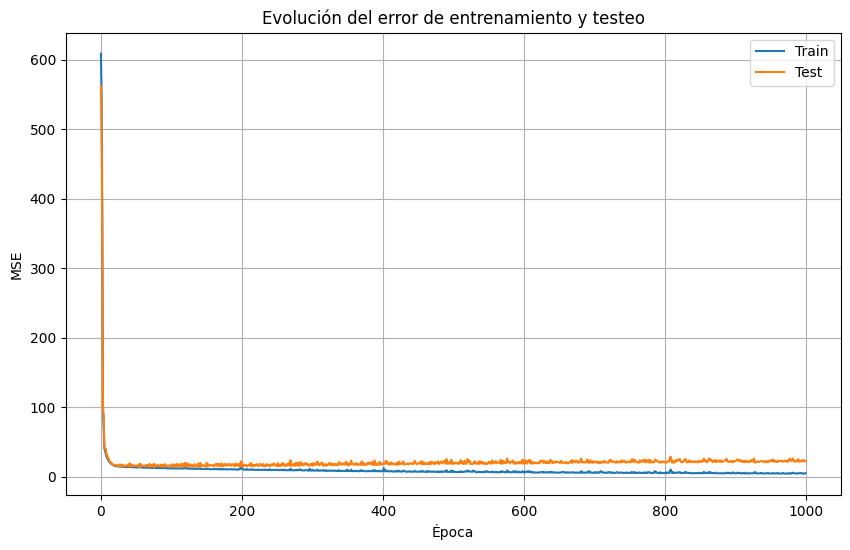

In [59]:
# Graficamos las curvas

plt.figure(figsize=(10, 6))

plt.plot(
    historial_train,
    label="Train"
)

plt.plot(
    historial_test,
    label="Test"
)

plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Evolución del error de entrenamiento y testeo")
plt.legend()
plt.grid()

plt.show()

Como visualmente quedo muy mal el grafico, no se llega apreciar nada, creo un 2do grafico mostrando menos epocas.

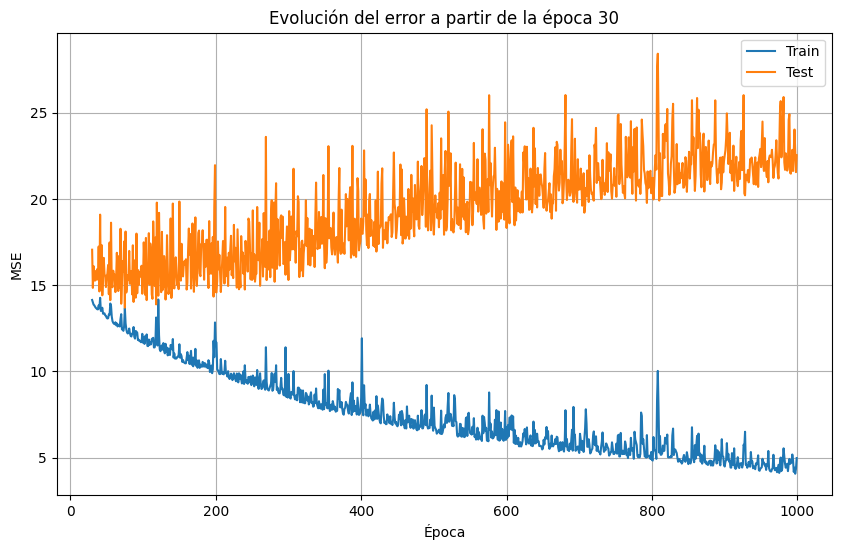

In [64]:
inicio = 30

plt.figure(figsize=(10, 6))

plt.plot(
    range(inicio, num_epocas),
    historial_train[inicio:],
    label="Train"
)

plt.plot(
    range(inicio, num_epocas),
    historial_test[inicio:],
    label="Test"
)

plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Evolución del error a partir de la época 30")
plt.legend()
plt.grid()

plt.show()

In [63]:
# Mostramos la info en una tabla

import numpy as np

mejor_epoca = np.argmin(historial_test)

print("Mejor época:", mejor_epoca + 1)
print(f"MSE Train: {historial_train[mejor_epoca]:.4f}")
print(f"MSE Test: {historial_test[mejor_epoca]:.4f}")

print("\nÚltima época:", len(historial_test))
print(f"MSE Train: {historial_train[-1]:.4f}")
print(f"MSE Test: {historial_test[-1]:.4f}")

Mejor época: 76
MSE Train: 13.6802
MSE Test: 13.6953

Última época: 1000
MSE Train: 4.9701
MSE Test: 22.5360


## Segunda conclusión:

Para observar el sobreajuste se entrenó una red neuronal de mayor complejidad durante 1000 épocas, registrando el MSE de entrenamiento y testeo en cada época. Se observa que inicialmente ambos errores disminuyen, indicando que la red está aprendiendo patrones que también permiten generalizar sobre datos no vistos. El menor MSE de testeo se obtuvo en la época 76, con un valor de 13.6953, mientras que el MSE de entrenamiento fue de 13.6802.

Al continuar el entrenamiento, el MSE de entrenamiento continúa disminuyendo hasta alcanzar 4.9701 en la época 1000. Sin embargo, el MSE de testeo aumenta hasta 22.5360. Esta separación entre ambas curvas evidencia un sobreajuste (overfitting): la red continúa ajustándose cada vez más a los datos de entrenamiento, pero pierde capacidad de generalización sobre el conjunto de testeo.

Por lo tanto, una mayor cantidad de épocas no implica necesariamente un mejor modelo. En este caso, detener el entrenamiento cerca del mínimo error de testeo permitiría obtener una mejor capacidad de generalización.


## Comparación de modelos: Regresión lineal vs Regresión con Pytorch

In [66]:
# Traemos los valores de las metricas MAE, MSE y R2 de la regresión lineal

y_pred_lr = model.predict(X_test_scaled)

# Métricas
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"MSE: {mse_lr:.4f}")
print(f"MAE: {mae_lr:.4f}")
print(f"R²: {r2_lr:.4f}")

MSE: 17.9392
MAE: 3.4861
R²: 0.6485


In [68]:
# Ahora traemos los valores de las metricas de la red neuronal de Pytorch (la 1ra que cree)

modelo.eval()

with torch.no_grad():
    pred_test_pytorch = modelo(X_test_tensor).numpy()

mse_pytorch = mean_squared_error(y_test, pred_test_pytorch)
mae_pytorch = mean_absolute_error(y_test, pred_test_pytorch)
r2_pytorch = r2_score(y_test, pred_test_pytorch)

print(f"MSE: {mse_pytorch:.4f}")
print(f"MAE: {mae_pytorch:.4f}")
print(f"R²: {r2_pytorch:.4f}")

MSE: 15.6747
MAE: 2.9232
R²: 0.6929


In [69]:
# Tabla comparativa

comparacion = pd.DataFrame({
    "Modelo": [
        "Regresión Lineal",
        "Red Neuronal PyTorch"
    ],
    "MSE": [
        mse_lr,
        mse_pytorch
    ],
    "MAE": [
        mae_lr,
        mae_pytorch
    ],
    "R²": [
        r2_lr,
        r2_pytorch
    ]
})

comparacion.round(4)

,Modelo,MSE,MAE,R²
0,Regresión Lineal,17.9392,3.4861,0.6485
1,Red Neuronal PyTorch,15.6747,2.9232,0.6929


## Conclusión final:

Al comparar la Regresión Lineal utilizada en AA1 con la red neuronal de PyTorch, se observa un mejor desempeño de la red neuronal en las tres métricas evaluadas.

La Regresión Lineal obtuvo un MSE de 17.9392, un MAE de 3.4861 y un R² de 0.6485. Por su parte, la red neuronal obtuvo un MSE de 15.6747, un MAE de 2.9232 y un R² de 0.6929. Esto representa una reducción aproximada del 12.6% en el MSE y del 16.1% en el MAE.

Además, el R² aumentó de 0.6485 a 0.6929, indicando que la red neuronal logró explicar una mayor proporción de la variabilidad del MPG en el conjunto de testeo. La mejora puede asociarse a que la red neuronal, mediante sus capas ocultas y funciones de activación ReLU, puede modelar relaciones no lineales entre las variables de entrada y la variable objetivo, mientras que la Regresión Lineal se encuentra limitada a relaciones lineales.

Cabe destacar que esta comparación esta hecha con el primer modelo de Pytorch que genere, no con el optimo encontrado en el segundo modelo. Por lo que es posible que la mejora en las metricas con Pytorch sea mayor.